In [1]:
import platform
from pathlib import Path
import requests

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    open("cmd_helper.py", "w").write(r.text)

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py")
    open("pip_helper.py", "w").write(r.text)

from pip_helper import pip_install

# pip_install("torch>=2.1", "torchvision", "Pillow", "gradio>=4.36", "opencv-python", "verovio", "--extra-index-url", "https://download.pytorch.org/whl/cpu")
# pip_install("-U", "openvino>=2025.0.0", "openvino-tokenizers>=2025.0.0", "nncf>=2.15.0")
# pip_install("transformers>=4.49", "git+https://github.com/huggingface/optimum-intel.git", "--extra-index-url", "https://download.pytorch.org/whl/cpu")

# if platform.system() == "Darwin":
#     pip_install("numpy<2.0")

In [2]:
import ipywidgets as widgets

model_id = "stepfun-ai/GOT-OCR-2.0-hf"
base_model_path = Path(model_id.split("/")[-1])

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

# collect_telemetry("got-ocr2.ipynb")

to_compress = widgets.Checkbox(value=True, description="Compress model")
to_compress

Checkbox(value=True, description='Compress model')

In [3]:
from cmd_helper import optimum_cli

model_path = base_model_path / ("INT4" if to_compress.value else "FP16")

if not model_path.exists():
    optimum_cli(model_id, model_path, additional_args={"weight-format": "int4" if to_compress.value else "fp16"})

In [4]:
from optimum.intel.openvino import OVModelForVisualCausalLM

/home/ea/work/py311/lib/python3.11/site-packages/openvino/runtime/__init__.py:10: DeprecationWarning: The `openvino.runtime` module is deprecated and will be removed in the 2026.0 release. Please replace `openvino.runtime` with `openvino`.
  warnings.warn(
2025-03-18 12:01:37.424539: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-18 12:01:37.438660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742284897.453803  467734 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742284897.458355  467734 cuda_blas.cc:1418] Unable 

In [5]:
from notebook_utils import device_widget

device = device_widget(default="AUTO", exclude=["NPU"])

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [6]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(model_path)

model = OVModelForVisualCausalLM.from_pretrained(model_path, device=device.value)

In [7]:
from PIL import Image
from io import BytesIO

def load_image(image_file):
    if isinstance(image_file, str) and image_file.startswith("https://"):
        response = requests.get(image_file)
        image = Image.open(BytesIO(response.content))
    else:
        image = Image.open(image_file)
    return image.convert("RGB")


test_image_path = Path("ov_docs.png")
test_image_url = "https://github.com/openvinotoolkit/openvino_notebooks/assets/29454499/aa46ef0c-c14d-4bab-8bb7-3b22fe73f6bc"

if not test_image_path.exists():
    image = load_image(test_image_url)
    image.save(test_image_path)
else:
    image = load_image(test_image_path)

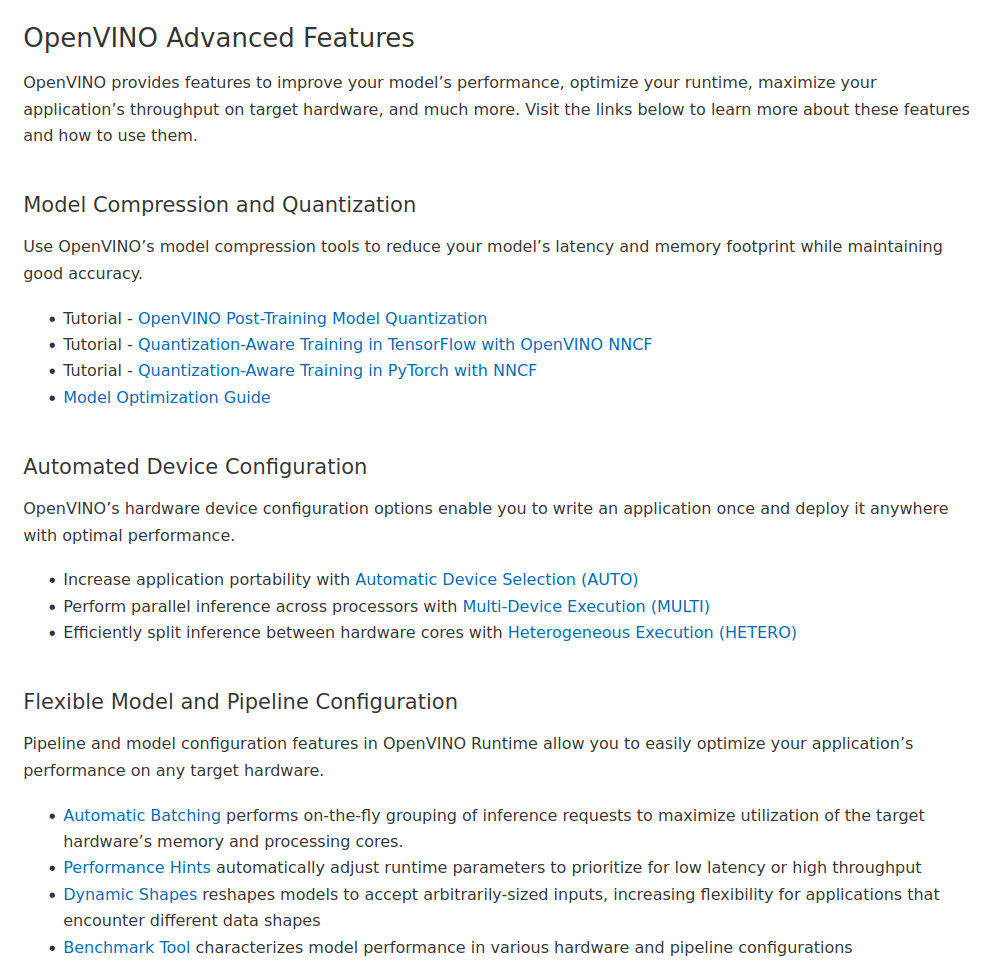

OpenVINO Advanced Features
OpenVINO provides features to improve your model’s performance, optimize your runtime, maximize your
application’s throughput on target hardware, and much more. Visit the links below to learn more about these features
and how to use them.
Model Compression and Quantization
Use OpenVINO’s model compression tools to reduce your model’s latency and memory footprint while maintaining
good accuracy.
Tutorial - OpenVINO Post-Training Model Quantization
Tutorial - Quantization-Aware Training in TensorFlow with OpenVINO NNCF
Tutorial - Quantization-Aware Training in PyTorch with NNCF
Model Optimization Guide
Automated Device Configuration
OpenVINO’s hardware device configuration options enable you to write an application once and deploy it anywhere
with optimal performance.
Increase application portability with Automatic Device Selection (AUTO)
Perform parallel inference across processors with Multi-Device Execution (MULTI)
Efficiently split inference between hardwar

In [8]:
from transformers import TextStreamer

inputs = processor(image, return_tensors="pt")
display(image)
generate_ids = model.generate(
    **inputs,
    do_sample=False,
    tokenizer=processor.tokenizer,
    stop_strings="<|im_end|>",
    max_new_tokens=4096,
    streamer=TextStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True)
)

Input image


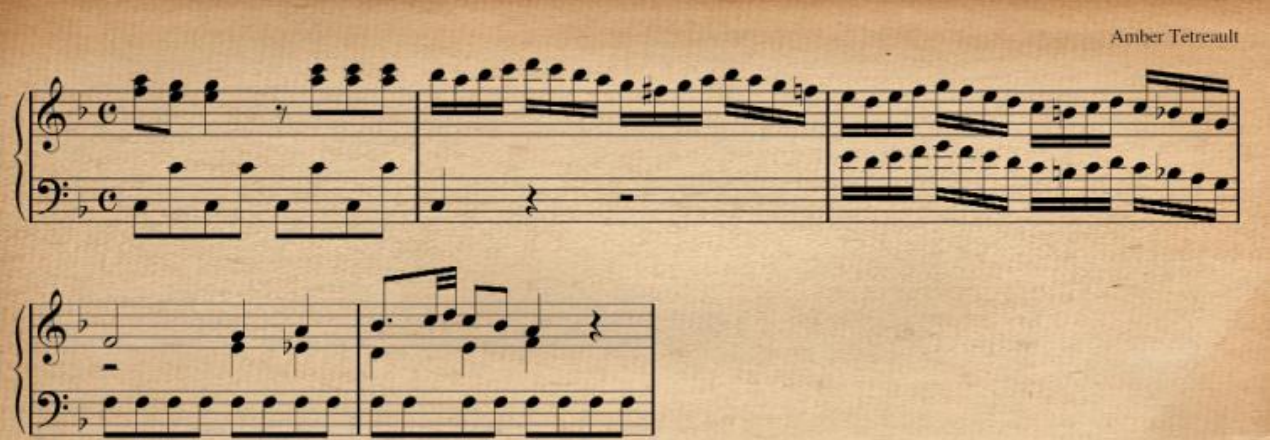

Generated


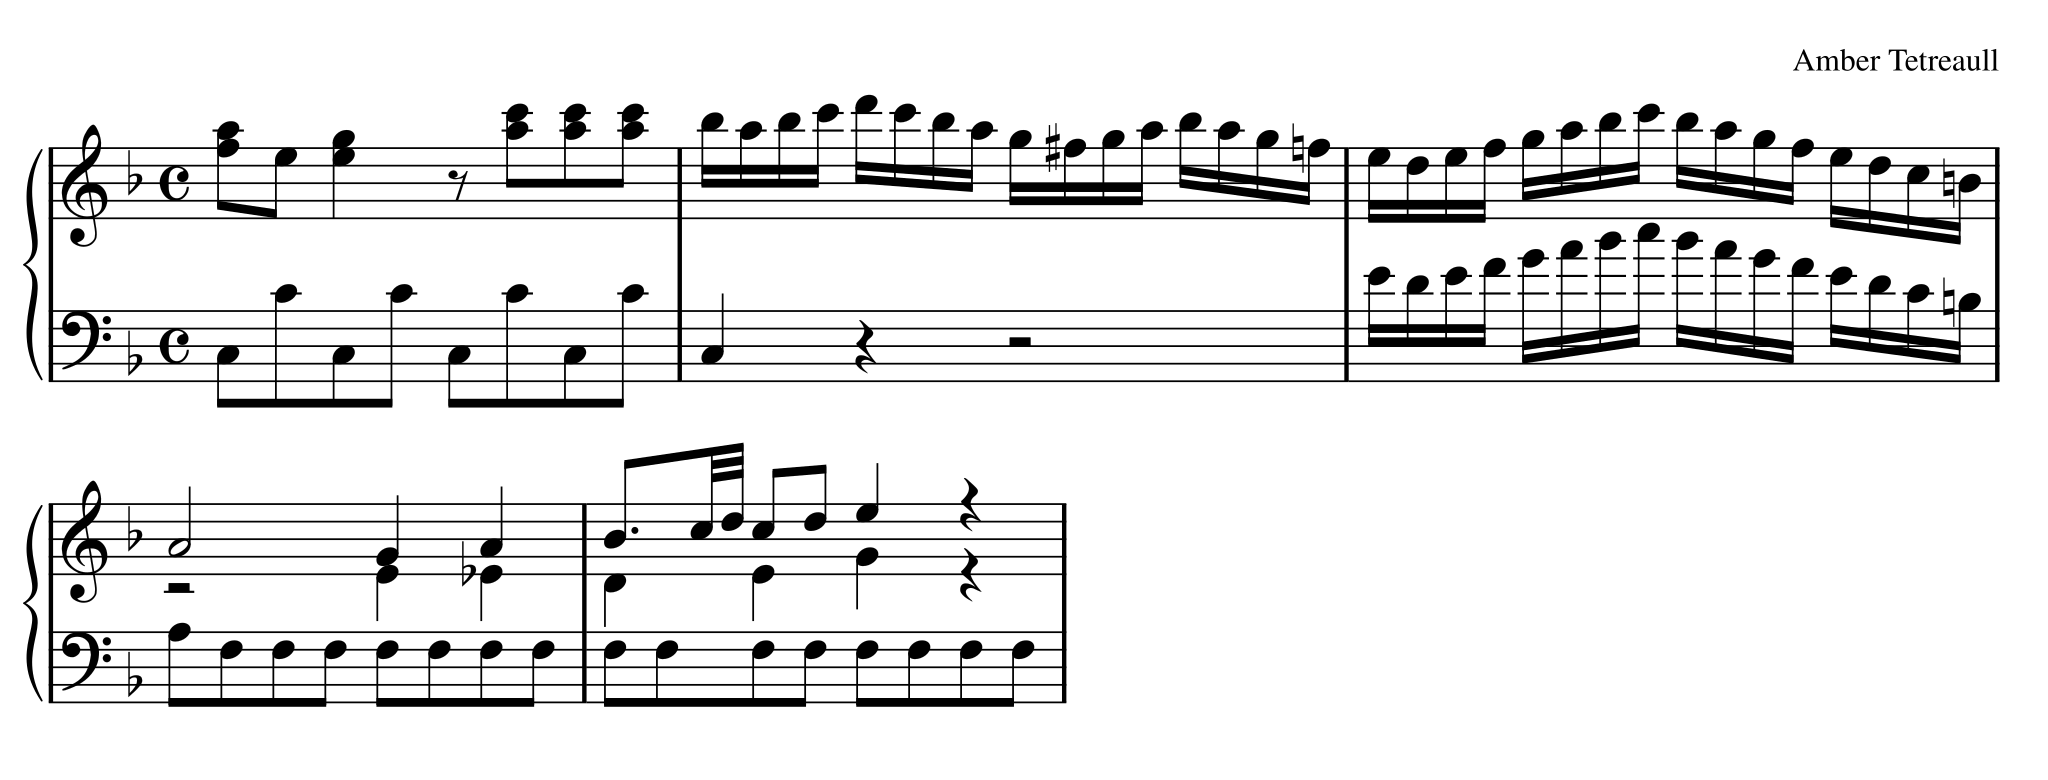

In [9]:
import verovio
music_image_path = Path("sheet_music.png")
music_image_url = "https://huggingface.co/datasets/hf-internal-testing/fixtures_got_ocr/resolve/main/sheet_music.png"

if not music_image_path.exists():
    music_image = load_image(music_image_url)
    music_image.save(music_image_path)
else:
    music_image = load_image(music_image_path)

print("Input image")
display(music_image)

inputs = processor(music_image, return_tensors="pt", format=True)

generate_ids = model.generate(
    **inputs,
    do_sample=False,
    tokenizer=processor.tokenizer,
    stop_strings="<|im_end|>",
    max_new_tokens=4096,
)

outputs = processor.decode(generate_ids[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)

tk = verovio.toolkit()
tk.loadData(outputs)
tk.setOptions(
    {
        "pageWidth": 2100,
        "pageHeight": 800,
        "footer": "none",
        "barLineWidth": 0.5,
        "beamMaxSlope": 15,
        "staffLineWidth": 0.2,
        "spacingStaff": 6,
    }
)

tk.getPageCount()
svg = tk.renderToSVG()
svg = svg.replace('overflow="inherit"', 'overflow="visible"')

with open("output.svg", "w") as f:
    f.write(svg)

from IPython.display import SVG

print("Generated")
display(SVG("output.svg"))